# Business problem


### The management team wants to forecast futurr sales to support inventory planning, budgeting, and business growth startegies.

### Goal: Predict  future monthly sales using historical sales data.

In [2]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("superstore_clean.csv")

In [4]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,order_month_name,order_quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_id            9994 non-null   int64  
 1   order_id          9994 non-null   object 
 2   order_date        9994 non-null   object 
 3   ship_date         9994 non-null   object 
 4   ship_mode         9994 non-null   object 
 5   customer_id       9994 non-null   object 
 6   customer_name     9994 non-null   object 
 7   segment           9994 non-null   object 
 8   country           9994 non-null   object 
 9   city              9994 non-null   object 
 10  state             9994 non-null   object 
 11  postal_code       9994 non-null   int64  
 12  region            9994 non-null   object 
 13  product_id        9994 non-null   object 
 14  category          9994 non-null   object 
 15  sub_category      9994 non-null   object 
 16  product_name      9994 non-null   object 


In [6]:
df.shape

(9994, 25)

In [7]:
df["order_date"] = pd.to_datetime(df["order_date"])

### Monthly Sales Aggeregation

In [8]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="order_date",
            freq='ME'
        )
    )["sales"]
    .sum()
    .reset_index()
)

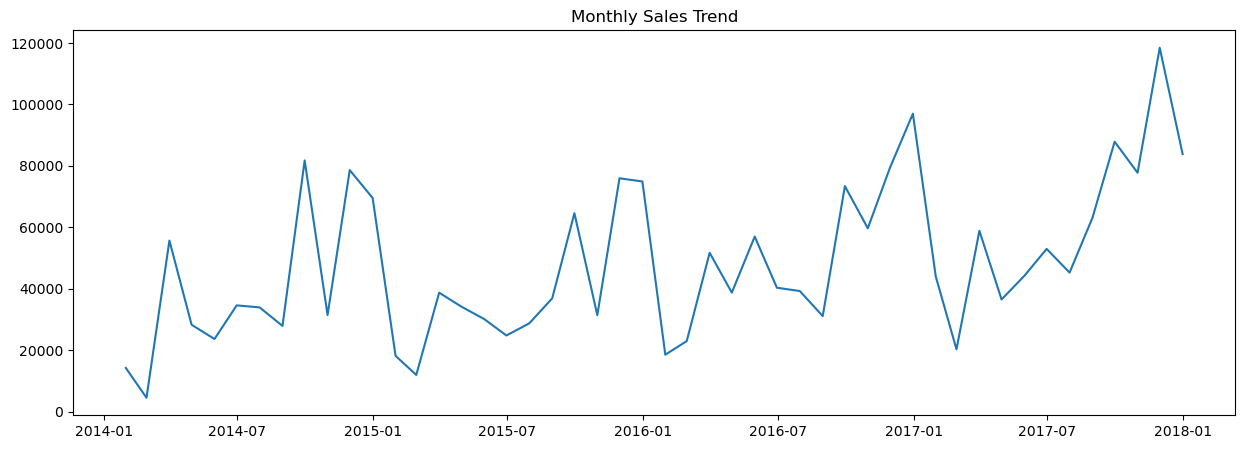

In [9]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["sales"]
)

plt.title("Monthly Sales Trend")
plt.show()

### Feature Engineering

In [10]:
monthly_sales["month_number"] = range(
    1,
    len(monthly_sales)+1
)

print(monthly_sales)

   order_date        sales  month_number
0  2014-01-31   14236.8950             1
1  2014-02-28    4519.8920             2
2  2014-03-31   55691.0090             3
3  2014-04-30   28295.3450             4
4  2014-05-31   23648.2870             5
5  2014-06-30   34595.1276             6
6  2014-07-31   33946.3930             7
7  2014-08-31   27909.4685             8
8  2014-09-30   81777.3508             9
9  2014-10-31   31453.3930            10
10 2014-11-30   78628.7167            11
11 2014-12-31   69545.6205            12
12 2015-01-31   18174.0756            13
13 2015-02-28   11951.4110            14
14 2015-03-31   38726.2520            15
15 2015-04-30   34195.2085            16
16 2015-05-31   30131.6865            17
17 2015-06-30   24797.2920            18
18 2015-07-31   28765.3250            19
19 2015-08-31   36898.3322            20
20 2015-09-30   64595.9180            21
21 2015-10-31   31404.9235            22
22 2015-11-30   75972.5635            23
23 2015-12-31   

### Define X and Y

In [11]:
X = monthly_sales[["month_number"]]
y = monthly_sales["sales"]

### Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Model Trainning


In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Prediction

In [14]:
y_pred = model.predict(X_test)

### Model Evaluation

In [15]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        y_pred
    )
)

MAE: 20460.74244429802


In [16]:
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )
)

RMSE: 24075.854608213576


In [17]:
print(
    "R2 Score:",
    r2_score(
        y_test,
        y_pred
    )
)

R2 Score: -1.6305122439113675


### Futurer Forecast

In [18]:
next_month = pd.DataFrame(
    {
        "month_number":[
            monthly_sales[
                "month_number"
            ].max()+1
        ]
    }
)

prediction = model.predict(
    next_month
)

prediction

array([76385.37330839])

# Conclusion

### The forecasting model predicts future monthly sales based on historical sales trends.

### This prediction can help management in:

### • Inventory Planning
### • Demand Forecasting
### • Budget Allocation
### • Sales Target Setting

In [19]:
monthly_sales.shape

(48, 3)

In [20]:
monthly_sales.head()

,order_date,sales,month_number
0,2014-01-31,14236.895,1
1,2014-02-28,4519.892,2
2,2014-03-31,55691.009,3
3,2014-04-30,28295.345,4
4,2014-05-31,23648.287,5


In [21]:
monthly_sales.shape

(48, 3)

In [22]:
monthly_sales.tail()

,order_date,sales,month_number
43,2017-08-31,63120.8880,44
44,2017-09-30,87866.6520,45
45,2017-10-31,77776.9232,46
46,2017-11-30,118447.8250,47
47,2017-12-31,83829.3188,48


In [23]:
monthly_sales.set_index(
    "order_date",
    inplace=True
)

monthly_sales.head()

,sales,month_number
order_date,,
2014-01-31,14236.895,1
2014-02-28,4519.892,2
2014-03-31,55691.009,3
2014-04-30,28295.345,4
2014-05-31,23648.287,5


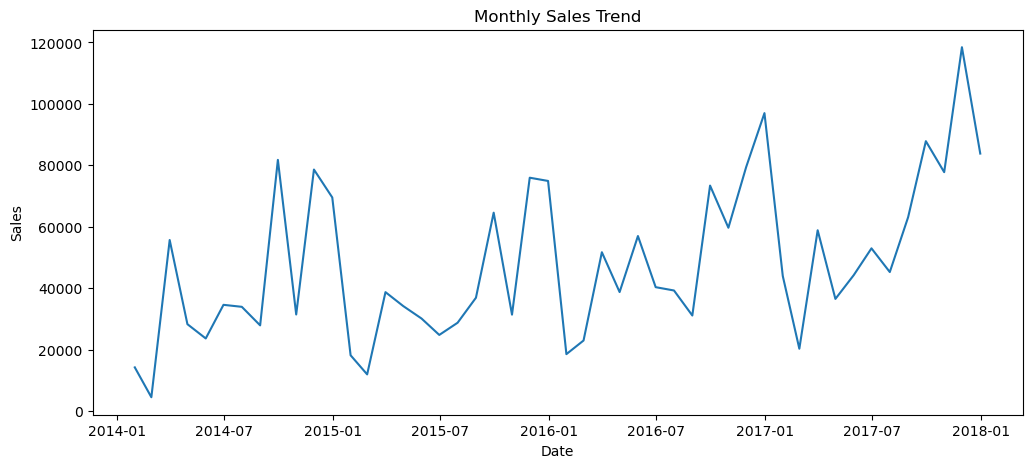

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index,
         monthly_sales["sales"])

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

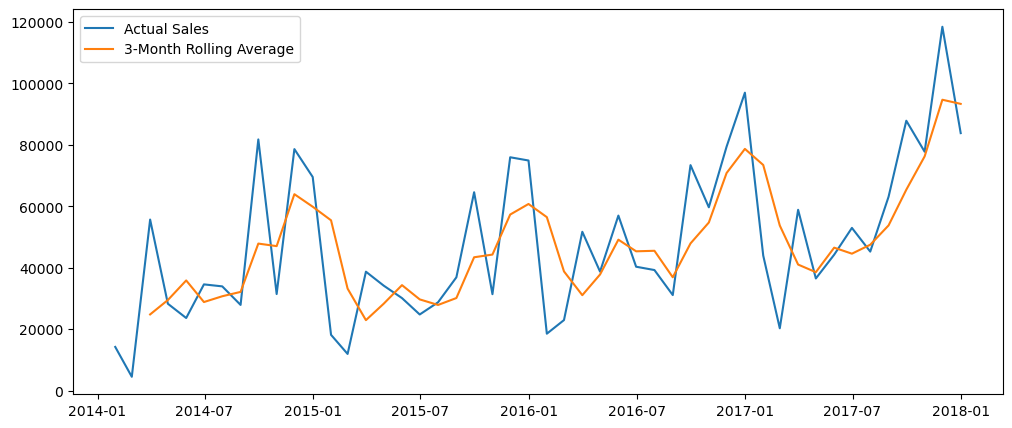

In [25]:
monthly_sales["rolling_avg"] = (
    monthly_sales["sales"]
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales["sales"],
    label="Actual Sales"
)

plt.plot(
    monthly_sales.index,
    monthly_sales["rolling_avg"],
    label="3-Month Rolling Average"
)

plt.legend()

plt.show()

In [26]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly_sales["sales"],
    order=(1,1,1)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -539.895
Date:                Thu, 04 Jun 2026   AIC                           1085.789
Time:                        19:17:57   BIC                           1091.340
Sample:                    01-31-2014   HQIC                          1087.878
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2278      0.262      0.868      0.386      -0.287       0.742
ma.L1         -0.8396      0.140     -5.979      0.000      -1.115      -0.564
sigma2      5.976e+08   6.93e-11   8.63e+18      0.0

C:\Users\Ujjal Mondal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Ujjal Mondal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Ujjal Mondal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [27]:
forecast = model_fit.forecast(steps=6)

print(forecast)

2018-01-31    75259.028080
2018-02-28    73306.799975
2018-03-31    72862.101575
2018-04-30    72760.803644
2018-05-31    72737.728970
2018-06-30    72732.472786
Freq: ME, Name: predicted_mean, dtype: float64


C:\Users\Ujjal Mondal\AppData\Local\Temp\ipykernel_21868\2778957171.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


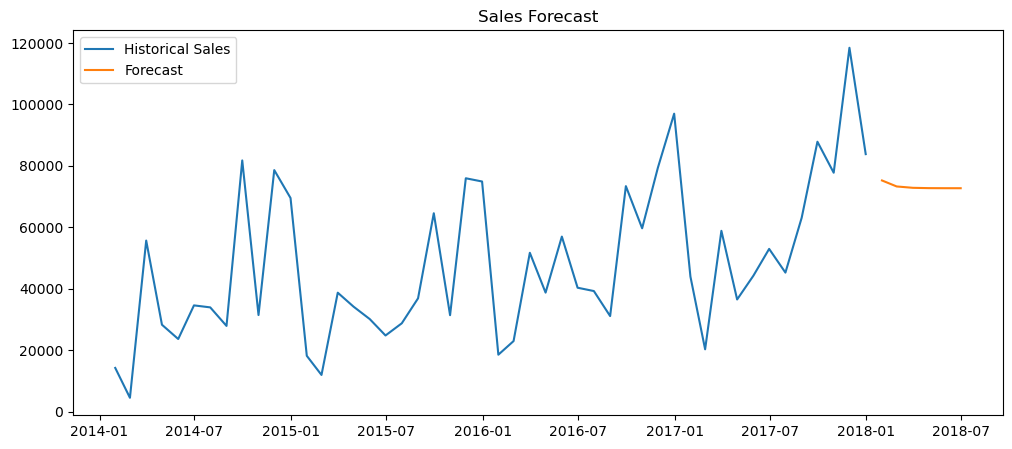

In [28]:
import matplotlib.pyplot as plt

forecast = model_fit.forecast(steps=6)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales["sales"],
    label="Historical Sales"
)

future_dates = pd.date_range(
    start=monthly_sales.index[-1],
    periods=7,
    freq="M"
)[1:]

plt.plot(
    future_dates,
    forecast,
    label="Forecast"
)

plt.legend()

plt.title("Sales Forecast")

plt.show()